# Laboratorio 1 - Series de Tiempo

Se trabaja principalmente con las categorías Turista + Excursionista. Las dos series analizadas son Aérea y Terrestre.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import boxcox_normmax
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

cwd = Path.cwd().resolve()
file_name = "Base_Migracion_2009-2026jun.xlsx"

candidates = [
    cwd / "../data/raw" / file_name,
    cwd / "data/raw" / file_name,
    cwd / file_name,
    Path("/mnt/data") / file_name,
]

DATA_PATH = next((p.resolve() for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró el archivo"
        f"{file_name}."
    )

if cwd.name == "notebooks":
    OUTPUT_DIR = cwd.parent / "data" / "processed" / "lab1"
else:
    OUTPUT_DIR = cwd / "lab1_outputs"

FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Archivo: {DATA_PATH}")
print(f"Resultados: {OUTPUT_DIR}")

df = pd.read_excel(DATA_PATH, sheet_name="Datos")
df.columns = df.columns.str.strip()

df["Viajero"] = pd.to_numeric(df["Viajero"], errors="coerce")
df["Año"] = pd.to_numeric(df["Año"], errors="coerce")
df["Mes cod"] = pd.to_numeric(df["Mes cod"], errors="coerce")

df["Fecha"] = pd.to_datetime(
    {"year": df["Año"], "month": df["Mes cod"], "day": 1},
    errors="coerce",
)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"Período: {df['Fecha'].min():%Y-%m} a {df['Fecha'].max():%Y-%m}")
display(df.head())

Archivo: C:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\raw\Base_Migracion_2009-2026jun.xlsx
Resultados: C:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\lab1
Filas: 161,036
Columnas: 14
Período: 2009-01 a 2026-06


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,Fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,2009-01-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0,2009-01-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0,2009-01-01
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0,2009-01-01
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0,2009-01-01


## 1. Análisis exploratorio general

Se revisan faltantes, duplicados, valores cero, datos decimales y valores atípicos.

Valores faltantes:


,Valores faltantes
Año,0
Mes cod,0
Mes,0
Vía,0
Frontera,0
País,0
Región,0
Región dos,0
Regiones OMT,0
MCEO,0


Registros duplicados exactos: 0
Registros con Viajero = 0: 54
Registros con Viajero decimal: 47,620


,Viajero
count,161036.000000
mean,324.697193
std,2387.745140
min,0.000000
25%,2.000000
50%,7.000000
75%,38.891667
max,92336.035067


Límite inferior IQR: -53.34
Límite superior IQR: 94.23
Valores marcados como atípicos por IQR: 26,390


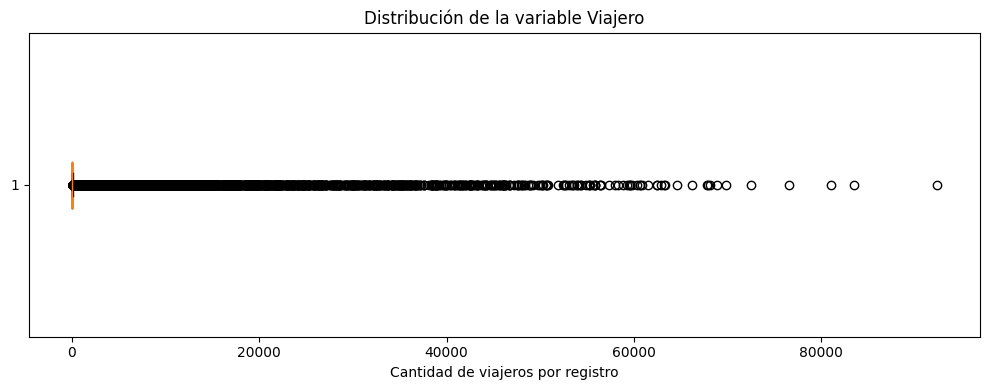

In [2]:
faltantes = df.isna().sum().rename("Valores faltantes").to_frame()
duplicados = int(df.duplicated().sum())
ceros_viajero = int((df["Viajero"] == 0).sum())
no_enteros = int((~np.isclose(df["Viajero"].dropna() % 1, 0)).sum())

print("Valores faltantes:")
display(faltantes)
print(f"Registros duplicados exactos: {duplicados:,}")
print(f"Registros con Viajero = 0: {ceros_viajero:,}")
print(f"Registros con Viajero decimal: {no_enteros:,}")

estadisticas = df["Viajero"].describe(
    percentiles=[0.25, 0.50, 0.75]
).to_frame("Viajero")
display(estadisticas)

q1 = df["Viajero"].quantile(0.25)
q3 = df["Viajero"].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

atipicos = df[
    (df["Viajero"] < limite_inferior)
    | (df["Viajero"] > limite_superior)
]

print(f"Límite inferior IQR: {limite_inferior:,.2f}")
print(f"Límite superior IQR: {limite_superior:,.2f}")
print(f"Valores marcados como atípicos por IQR: {len(atipicos):,}")

plt.figure(figsize=(10, 4))
plt.boxplot(df["Viajero"].dropna(), vert=False)
plt.title("Distribución de la variable Viajero")
plt.xlabel("Cantidad de viajeros por registro")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_boxplot_viajero.png", dpi=160)
plt.show()

resumen_calidad = pd.DataFrame(
    {
        "Indicador": [
            "Filas",
            "Columnas originales",
            "Faltantes totales",
            "Duplicados exactos",
            "Valores cero en Viajero",
            "Valores decimales en Viajero",
            "Atípicos según IQR",
        ],
        "Valor": [
            len(df),
            13,
            int(df.isna().sum().sum()),
            duplicados,
            ceros_viajero,
            no_enteros,
            len(atipicos),
        ],
    }
)
resumen_calidad.to_csv(
    OUTPUT_DIR / "resumen_calidad.csv",
    index=False,
    encoding="utf-8-sig",
)

Los valores identificados por IQR no se eliminan automáticamente, porque la tabla está desagregada por varias categorías y los registros grandes pueden representar flujos reales.

In [3]:
tipos_consistentes = ["Turista", "Excursionista"]
df_consistente = df[df["Tipo de Viajero"].isin(tipos_consistentes)].copy()

print("Tipos de viajero encontrados:")
display(
    df.groupby("Tipo de Viajero", dropna=False)["Viajero"]
      .sum()
      .sort_values(ascending=False)
      .to_frame("Viajeros")
)
print(f"Registros comparables: {len(df_consistente):,}")
print(
    "Viajeros acumulados en el subconjunto comparable:",
    f"{df_consistente['Viajero'].sum():,.0f}",
)

Tipos de viajero encontrados:


,Viajeros
Tipo de Viajero,
Turista,3.764273e+07
Excursionista,9.069184e+06
Viajero,4.471622e+06
Cruceristas,1.104402e+06


Registros comparables: 137,642
Viajeros acumulados en el subconjunto comparable: 46,711,913


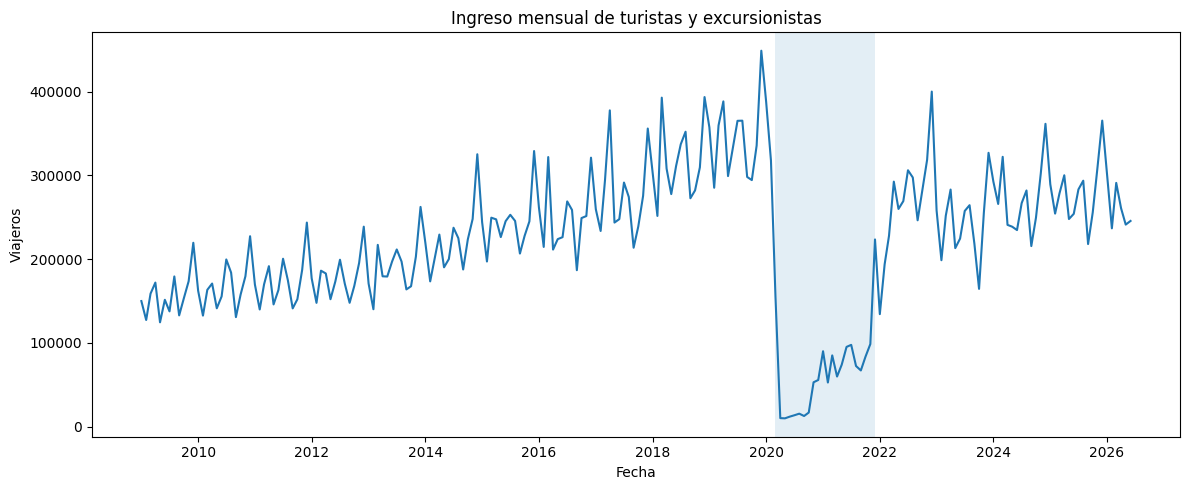

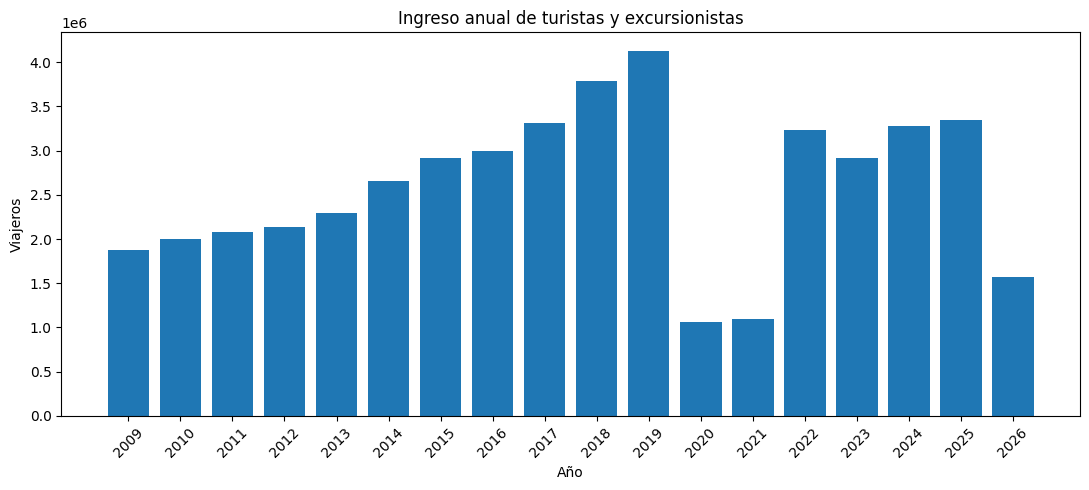

,Viajeros
Fecha,
2009-01-01,1.880183e+06
2010-01-01,2.004784e+06
2011-01-01,2.079715e+06
2012-01-01,2.139541e+06
2013-01-01,2.289703e+06
2014-01-01,2.660177e+06
2015-01-01,2.917886e+06
2016-01-01,2.997027e+06
2017-01-01,3.307651e+06


Variación 2020 frente a 2019: -74.35%
Variación 2025 frente a 2019: -18.87%
2026 contiene únicamente enero-junio.


In [4]:
serie_total = (
    df_consistente.groupby("Fecha")["Viajero"]
    .sum()
    .sort_index()
    .asfreq("MS", fill_value=0)
)
total_anual = serie_total.resample("YS").sum()

plt.figure(figsize=(12, 5))
plt.plot(serie_total.index, serie_total.values)
plt.axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2021-12-01"),
    alpha=0.12,
)
plt.title("Ingreso mensual de turistas y excursionistas")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_total_mensual.png", dpi=160)
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(total_anual.index.year, total_anual.values)
plt.title("Ingreso anual de turistas y excursionistas")
plt.xlabel("Año")
plt.ylabel("Viajeros")
plt.xticks(total_anual.index.year, rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_total_anual.png", dpi=160)
plt.show()

display(total_anual.rename("Viajeros").to_frame())

variacion_2020 = (
    total_anual.loc["2020-01-01"] / total_anual.loc["2019-01-01"] - 1
) * 100
recuperacion_2025 = (
    total_anual.loc["2025-01-01"] / total_anual.loc["2019-01-01"] - 1
) * 100

print(f"Variación 2020 frente a 2019: {variacion_2020:.2f}%")
print(f"Variación 2025 frente a 2019: {recuperacion_2025:.2f}%")
print("2026 contiene únicamente enero-junio.")

Top de países o mercados:


,Viajeros
País,
El Salvador,1.407914e+07
Guatemala,1.387039e+07
Estados Unidos de América,6.965680e+06
Honduras,2.520974e+06
México,1.678423e+06
Belice,9.161011e+05
Costa Rica,8.602407e+05
Nicaragua,8.111454e+05
Colombia,5.494947e+05


Top de regiones geográficas:


,Viajeros
Región dos,
América Del Centro,3.328393e+07
América Del Norte,9.160810e+06
Europa,2.149271e+06
América Del Sur y el Caribe,1.413590e+06
Asia,4.103335e+05
Oceanía,1.355054e+05
Oriente Medio,1.337352e+05
Otros Paises Del Mundo,2.391430e+04
0,8.210000e+02


Vías de ingreso:


,Viajeros
Vía,
Terrestre,2.759225e+07
Aérea,1.901942e+07
Marítima,1.002410e+05


Fronteras principales:


,Viajeros
Frontera,
01 La Aurora,1.898998e+07
07 Valle Nuevo,1.014305e+07
09 San Cristóbal,4.183632e+06
08 Pedro de Alvarado,3.764229e+06
10 La Ermita (Nueva Anguiatú),2.587072e+06
20 Melchor de Mencos,1.782864e+06
13 El Cinchado / El Corinto,1.213485e+06
11 Agua Caliente,9.224195e+05
12 El Florido,9.103735e+05


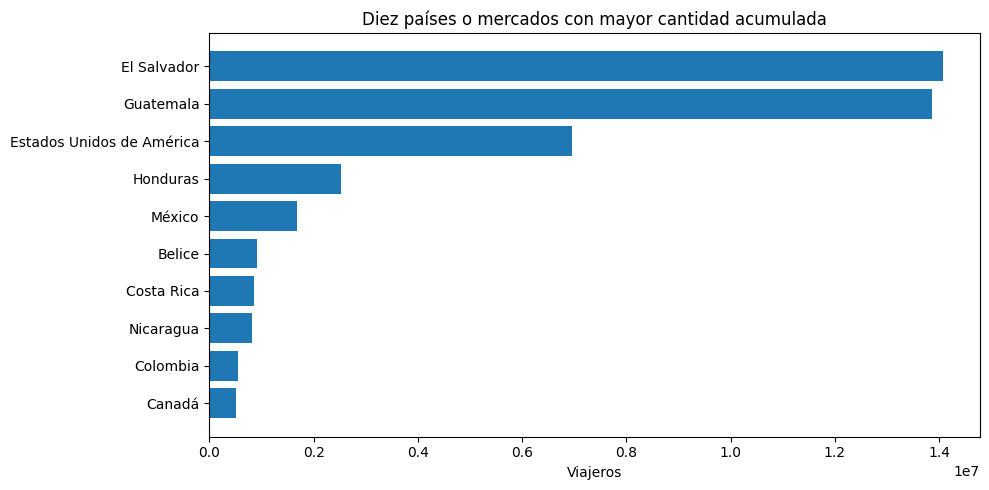

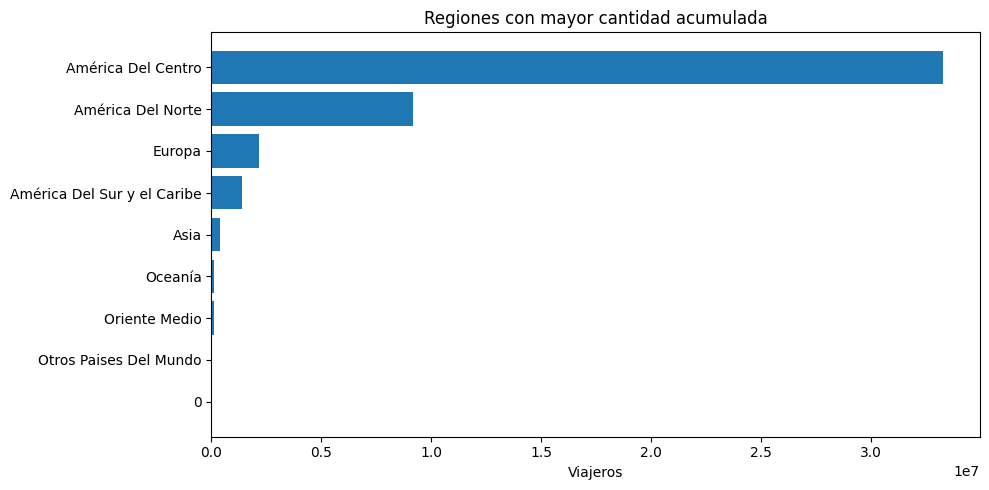

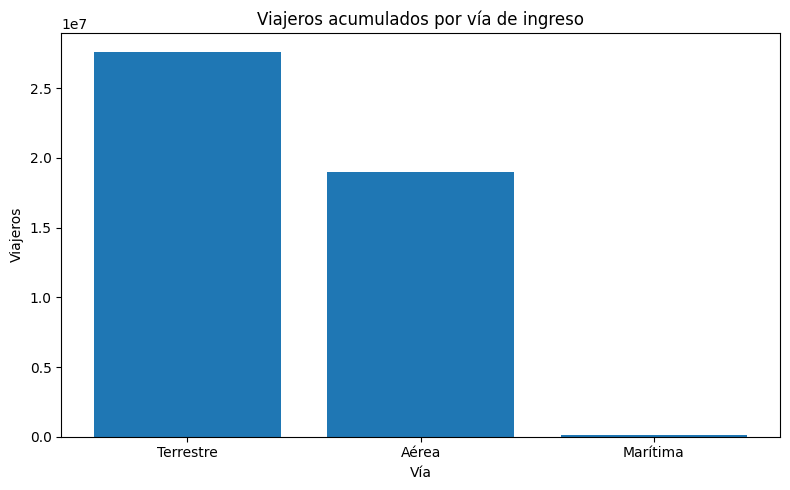

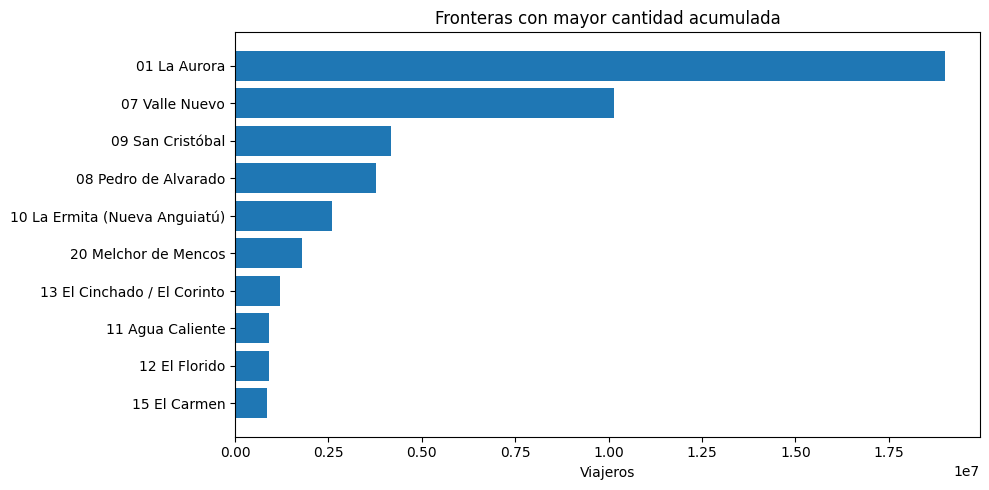

In [5]:
def tabla_top(columna, n=10):
    return (
        df_consistente.groupby(columna)["Viajero"]
        .sum()
        .sort_values(ascending=False)
        .head(n)
        .rename("Viajeros")
        .to_frame()
    )

top_paises = tabla_top("País", 10)
top_regiones = tabla_top("Región dos", 10)
top_vias = tabla_top("Vía", 3)
top_fronteras = tabla_top("Frontera", 10)

print("Top de países o mercados:")
display(top_paises)
print("Top de regiones geográficas:")
display(top_regiones)
print("Vías de ingreso:")
display(top_vias)
print("Fronteras principales:")
display(top_fronteras)

for nombre, tabla in [
    ("top_paises", top_paises),
    ("top_regiones", top_regiones),
    ("top_vias", top_vias),
    ("top_fronteras", top_fronteras),
]:
    tabla.to_csv(OUTPUT_DIR / f"{nombre}.csv", encoding="utf-8-sig")

plt.figure(figsize=(10, 5))
plt.barh(top_paises.index[::-1], top_paises["Viajeros"][::-1])
plt.title("Diez países o mercados con mayor cantidad acumulada")
plt.xlabel("Viajeros")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_top_paises.png", dpi=160)
plt.show()

plt.figure(figsize=(10, 5))
plt.barh(top_regiones.index[::-1], top_regiones["Viajeros"][::-1])
plt.title("Regiones con mayor cantidad acumulada")
plt.xlabel("Viajeros")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_top_regiones.png", dpi=160)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(top_vias.index, top_vias["Viajeros"])
plt.title("Viajeros acumulados por vía de ingreso")
plt.xlabel("Vía")
plt.ylabel("Viajeros")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_vias_ingreso.png", dpi=160)
plt.show()

plt.figure(figsize=(10, 5))
plt.barh(top_fronteras.index[::-1], top_fronteras["Viajeros"][::-1])
plt.title("Fronteras con mayor cantidad acumulada")
plt.xlabel("Viajeros")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_top_fronteras.png", dpi=160)
plt.show()

## 2. División cronológica 70/30

In [6]:
fechas = pd.Index(sorted(df_consistente["Fecha"].dropna().unique()))
n_train = int(len(fechas) * 0.70)

fecha_fin_train = pd.Timestamp(fechas[n_train - 1])
fecha_inicio_test = pd.Timestamp(fechas[n_train])

train = df_consistente[df_consistente["Fecha"] <= fecha_fin_train].copy()
test = df_consistente[df_consistente["Fecha"] >= fecha_inicio_test].copy()

print(f"Meses totales: {len(fechas)}")
print(
    f"Entrenamiento: {n_train} meses, "
    f"{fechas[0]:%Y-%m} a {fecha_fin_train:%Y-%m}"
)
print(
    f"Prueba: {len(fechas) - n_train} meses, "
    f"{fecha_inicio_test:%Y-%m} a {fechas[-1]:%Y-%m}"
)

series_vias = (
    df_consistente.pivot_table(
        index="Fecha",
        columns="Vía",
        values="Viajero",
        aggfunc="sum",
        fill_value=0,
    )
    .sort_index()
    .asfreq("MS", fill_value=0)
)

series_vias.to_csv(
    OUTPUT_DIR / "series_mensuales_vias.csv",
    encoding="utf-8-sig",
)
display(series_vias.head())

Meses totales: 210
Entrenamiento: 147 meses, 2009-01 a 2021-03
Prueba: 63 meses, 2021-04 a 2026-06


Vía,Aérea,Marítima,Terrestre
Fecha,,,
2009-01-01,81693.0,809,67442.029345
2009-02-01,70099.0,938,56266.692203
2009-03-01,84494.0,1190,73111.673819
2009-04-01,80618.0,1498,89897.467694
2009-05-01,64621.0,1040,58898.524351


La división se realiza por meses y no por filas aleatorias, para evitar fuga de información.

## 3. Funciones para analizar las series

In [7]:
def prueba_adf(serie, nombre):
    resultado = adfuller(serie.dropna(), autolag="AIC")
    return {
        "Transformación": nombre,
        "Estadístico ADF": resultado[0],
        "p-value": resultado[1],
        "Lags usados": resultado[2],
        "Observaciones": resultado[3],
        "Conclusión 5%": (
            "Estacionaria en media"
            if resultado[1] < 0.05
            else "No estacionaria en media"
        ),
    }


def analizar_serie(nombre, serie_completa, fecha_corte):
    serie_completa = serie_completa.asfreq("MS", fill_value=0).astype(float)
    serie_train = serie_completa.loc[:fecha_corte]
    serie_test = serie_completa.loc[fecha_inicio_test:]

    print("=" * 70)
    print(f"SERIE: {nombre}")
    print("=" * 70)
    print(f"Inicio: {serie_completa.index.min():%Y-%m}")
    print(f"Fin: {serie_completa.index.max():%Y-%m}")
    print("Frecuencia: mensual, 12 observaciones por año")
    print(f"Observaciones: {len(serie_completa)}")
    print(f"Entrenamiento: {len(serie_train)}")
    print(f"Prueba: {len(serie_test)}")
    print(
        f"Mínimo: {serie_completa.min():,.0f} "
        f"({serie_completa.idxmin():%Y-%m})"
    )
    print(
        f"Máximo: {serie_completa.max():,.0f} "
        f"({serie_completa.idxmax():%Y-%m})"
    )

    plt.figure(figsize=(12, 5))
    plt.plot(serie_completa.index, serie_completa.values, label=nombre)
    plt.axvline(fecha_inicio_test, linestyle="--", label="Inicio de prueba")
    plt.axvspan(
        pd.Timestamp("2020-03-01"),
        pd.Timestamp("2021-12-01"),
        alpha=0.12,
        label="Pandemia y recuperación inicial",
    )
    plt.title(f"Serie mensual: {nombre}")
    plt.xlabel("Fecha")
    plt.ylabel("Viajeros")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"serie_{nombre.lower().replace('é', 'e')}.png",
        dpi=160,
    )
    plt.show()

    media_movil = serie_train.rolling(12).mean()
    desv_movil = serie_train.rolling(12).std()

    plt.figure(figsize=(12, 5))
    plt.plot(serie_train.index, serie_train.values, label="Serie")
    plt.plot(media_movil.index, media_movil.values, label="Media móvil 12 meses")
    plt.title(f"{nombre}: serie y media móvil")
    plt.xlabel("Fecha")
    plt.ylabel("Viajeros")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(desv_movil.index, desv_movil.values)
    plt.title(f"{nombre}: desviación estándar móvil de 12 meses")
    plt.xlabel("Fecha")
    plt.ylabel("Desviación estándar")
    plt.tight_layout()
    plt.show()

    log_serie = np.log1p(serie_completa)
    descomposicion = seasonal_decompose(
        log_serie,
        model="additive",
        period=12,
        extrapolate_trend="freq",
    )

    for componente, valores in [
        ("observada", descomposicion.observed),
        ("tendencia", descomposicion.trend),
        ("estacional", descomposicion.seasonal),
        ("residuos", descomposicion.resid),
    ]:
        plt.figure(figsize=(12, 4))
        plt.plot(valores.index, valores.values)
        plt.title(f"{nombre}: componente {componente}")
        plt.xlabel("Fecha")
        plt.ylabel("Valor")
        plt.tight_layout()
        plt.show()

    log_train = np.log1p(serie_train)
    diff_log_train = log_train.diff().dropna()
    diff_estacional = diff_log_train.diff(12).dropna()

    resultados_adf = pd.DataFrame(
        [
            prueba_adf(serie_train, "Serie original"),
            prueba_adf(log_train, "log(1 + x)"),
            prueba_adf(diff_log_train, "Primera diferencia de log(1 + x)"),
            prueba_adf(
                diff_estacional,
                "Primera diferencia + diferencia estacional 12",
            ),
        ]
    )
    print("Prueba de Dickey-Fuller aumentada:")
    display(resultados_adf)

    plot_acf(serie_train, lags=24)
    plt.title(f"{nombre}: ACF de la serie original")
    plt.tight_layout()
    plt.show()

    plot_pacf(serie_train, lags=24, method="ywm")
    plt.title(f"{nombre}: PACF de la serie original")
    plt.tight_layout()
    plt.show()

    plot_acf(diff_log_train, lags=24)
    plt.title(f"{nombre}: ACF de la primera diferencia logarítmica")
    plt.tight_layout()
    plt.show()

    plot_pacf(diff_log_train, lags=24, method="ywm")
    plt.title(f"{nombre}: PACF de la primera diferencia logarítmica")
    plt.tight_layout()
    plt.show()

    lambda_boxcox = boxcox_normmax(serie_train.values + 1, method="mle")
    anual = serie_completa.resample("YS").sum()
    caida_2020 = (
        anual.loc["2020-01-01"] / anual.loc["2019-01-01"] - 1
    ) * 100
    recuperacion_2025 = (
        anual.loc["2025-01-01"] / anual.loc["2019-01-01"] - 1
    ) * 100

    resumen = {
        "Serie": nombre,
        "Inicio": serie_completa.index.min().strftime("%Y-%m"),
        "Fin": serie_completa.index.max().strftime("%Y-%m"),
        "Frecuencia": "Mensual (12/año)",
        "Observaciones": len(serie_completa),
        "Media": serie_completa.mean(),
        "Desviación estándar": serie_completa.std(),
        "Coeficiente de variación": serie_completa.std() / serie_completa.mean(),
        "Mínimo": serie_completa.min(),
        "Fecha mínimo": serie_completa.idxmin().strftime("%Y-%m"),
        "Máximo": serie_completa.max(),
        "Fecha máximo": serie_completa.idxmax().strftime("%Y-%m"),
        "ADF p-value original": resultados_adf.loc[
            resultados_adf["Transformación"] == "Serie original",
            "p-value",
        ].iloc[0],
        "ADF p-value primera diferencia": resultados_adf.loc[
            resultados_adf["Transformación"]
            == "Primera diferencia de log(1 + x)",
            "p-value",
        ].iloc[0],
        "Lambda Box-Cox": lambda_boxcox,
        "Caída 2020 vs. 2019 (%)": caida_2020,
        "2025 vs. 2019 (%)": recuperacion_2025,
    }
    return resumen, resultados_adf

## 4. Series Aérea y Terrestre

SERIE: Aérea
Inicio: 2009-01
Fin: 2026-06
Frecuencia: mensual, 12 observaciones por año
Observaciones: 210
Entrenamiento: 147
Prueba: 63
Mínimo: 489 (2020-04)
Máximo: 158,463 (2022-12)


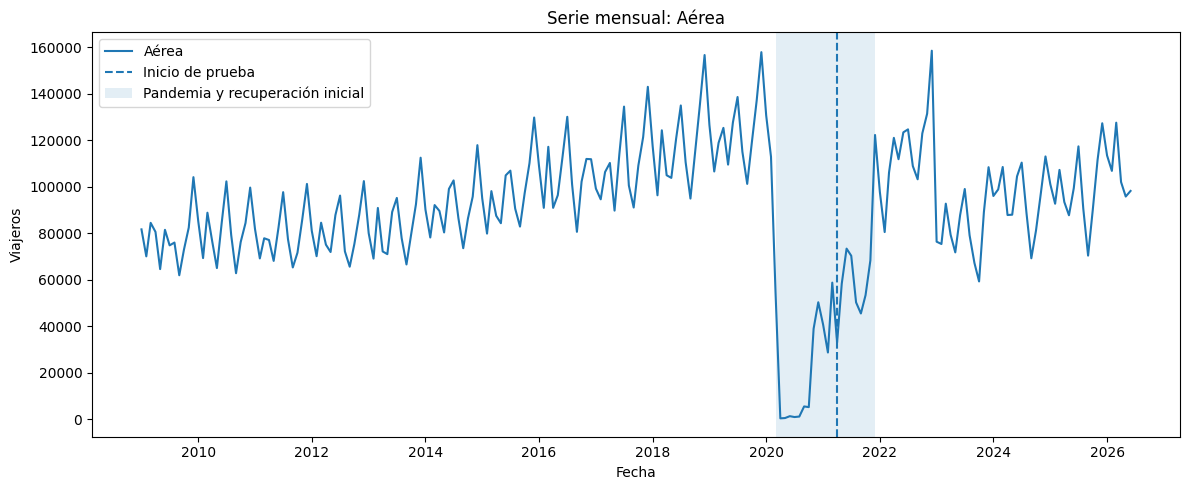

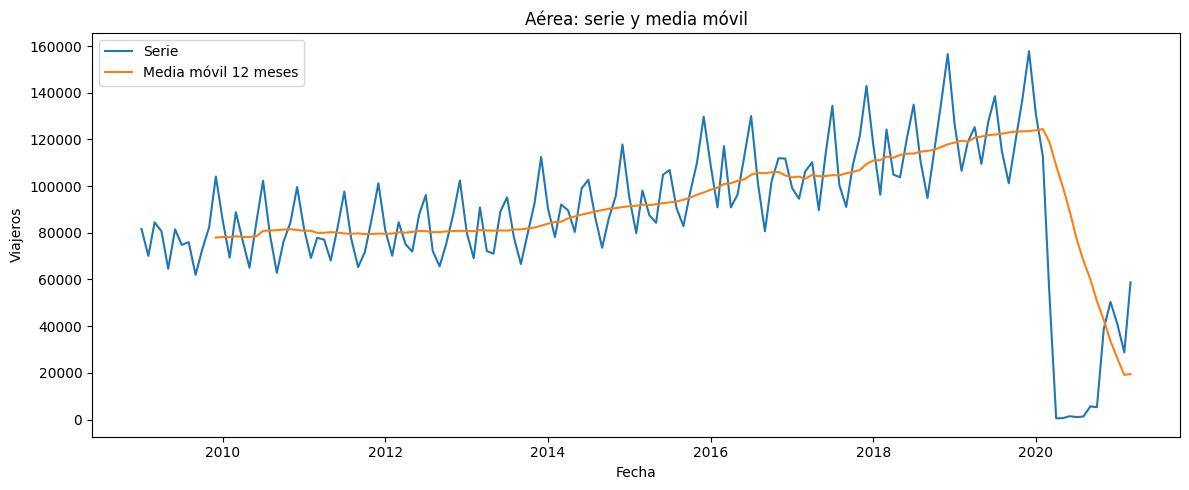

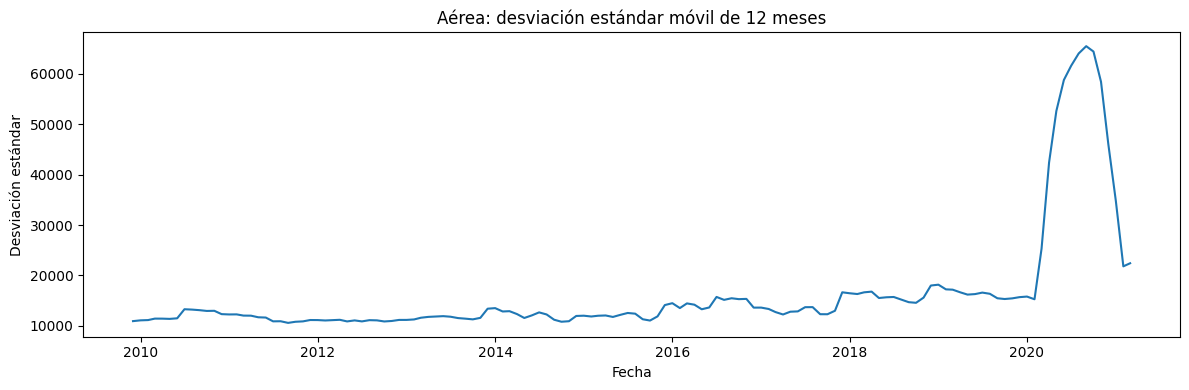

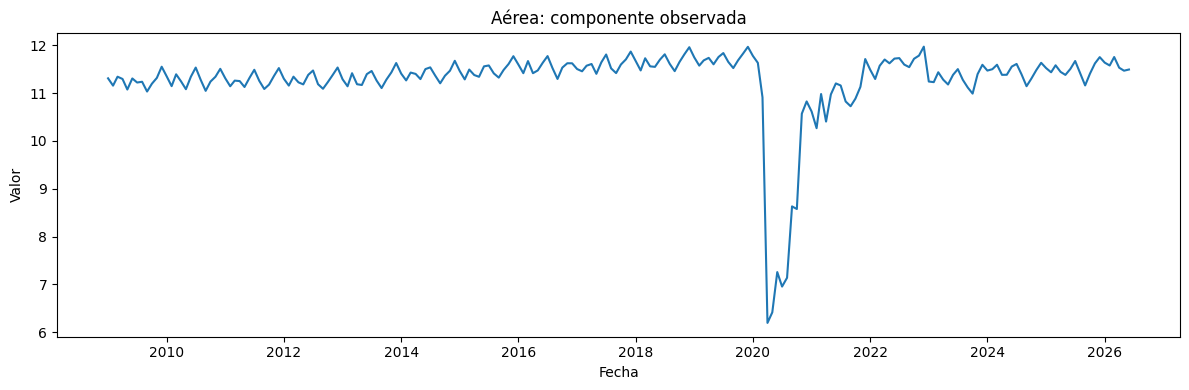

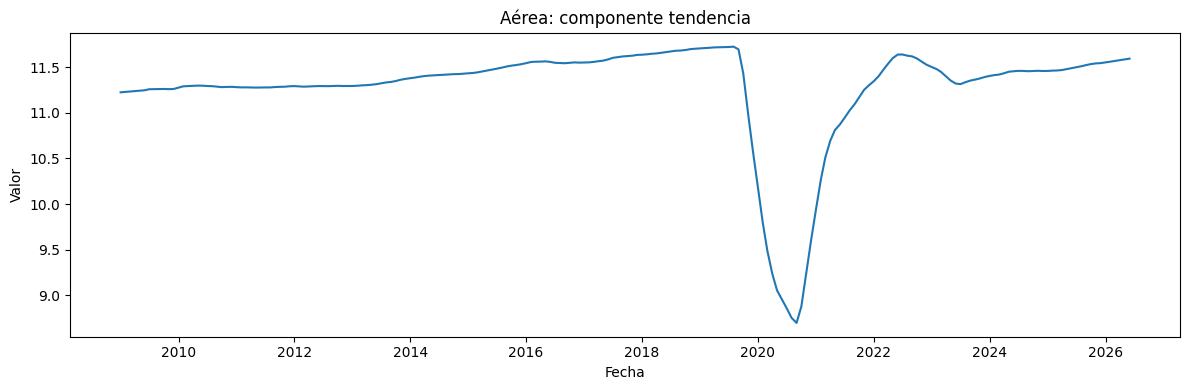

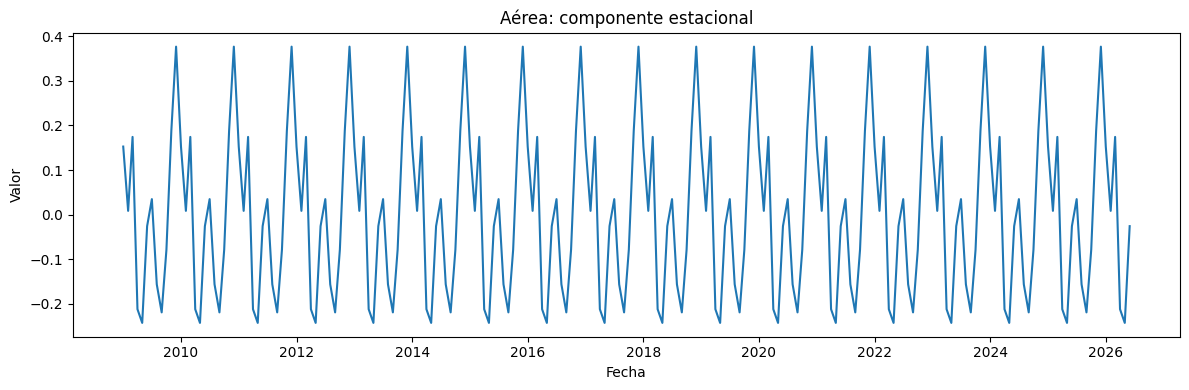

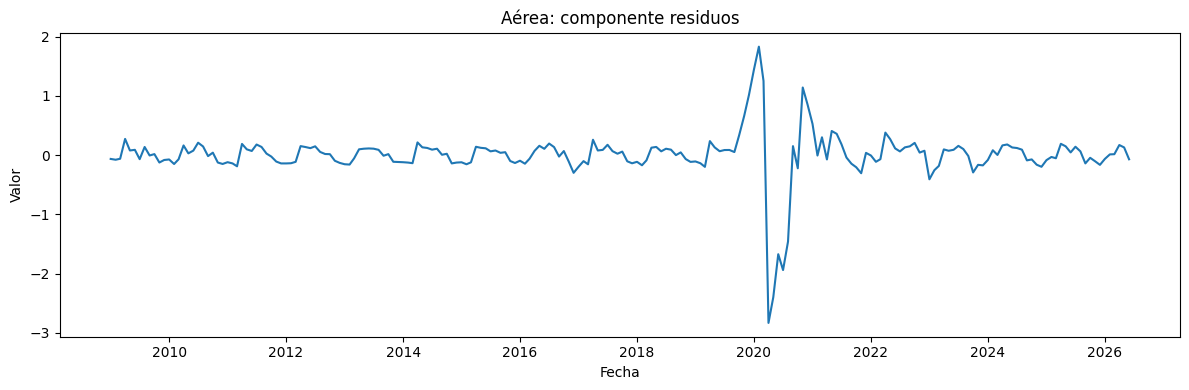

Prueba de Dickey-Fuller aumentada:


,Transformación,Estadístico ADF,p-value,Lags usados,Observaciones,Conclusión 5%
0,Serie original,-2.367258,1.511917e-01,14,132,No estacionaria en media
1,log(1 + x),-2.031326,2.730091e-01,12,134,No estacionaria en media
2,Primera diferencia de log(1 + x),-3.088850,2.738945e-02,11,134,Estacionaria en media
3,Primera diferencia + diferencia estacional 12,-6.224743,5.121068e-08,11,122,Estacionaria en media


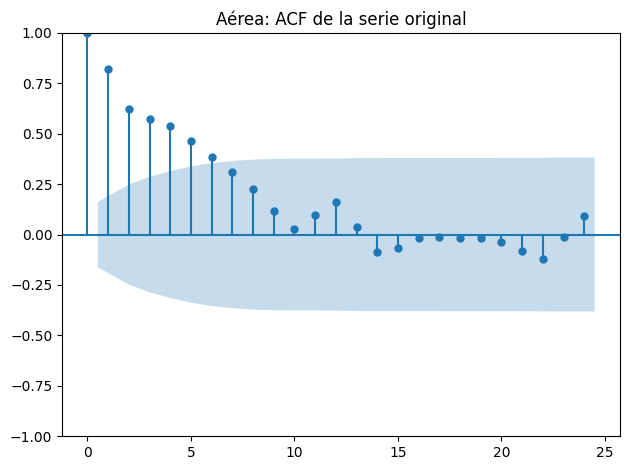

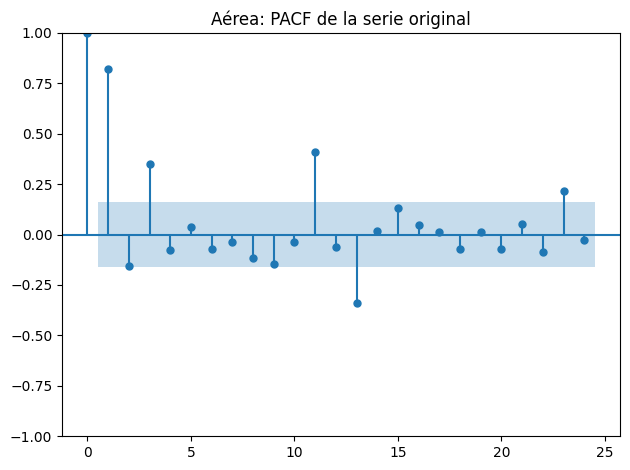

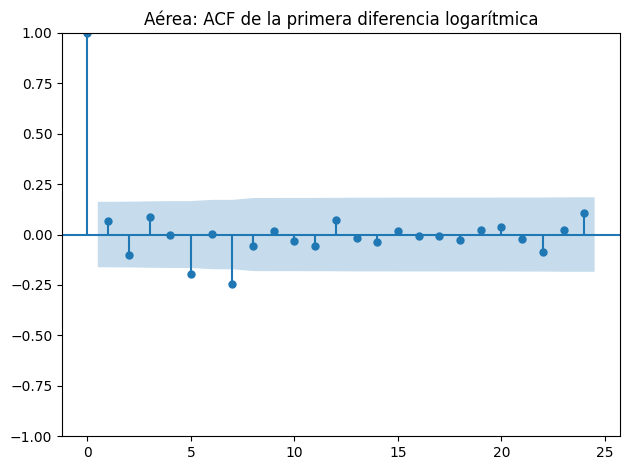

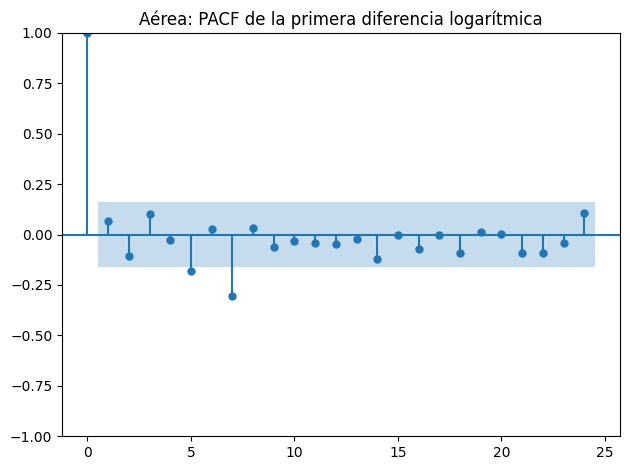

SERIE: Terrestre
Inicio: 2009-01
Fin: 2026-06
Frecuencia: mensual, 12 observaciones por año
Observaciones: 210
Entrenamiento: 147
Prueba: 63
Mínimo: 5,240 (2020-12)
Máximo: 291,272 (2019-12)


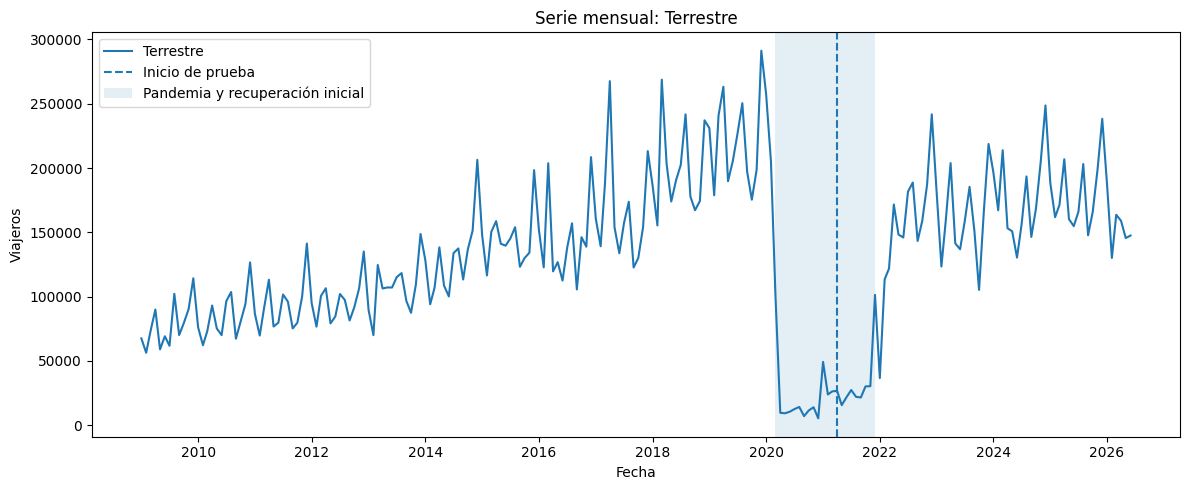

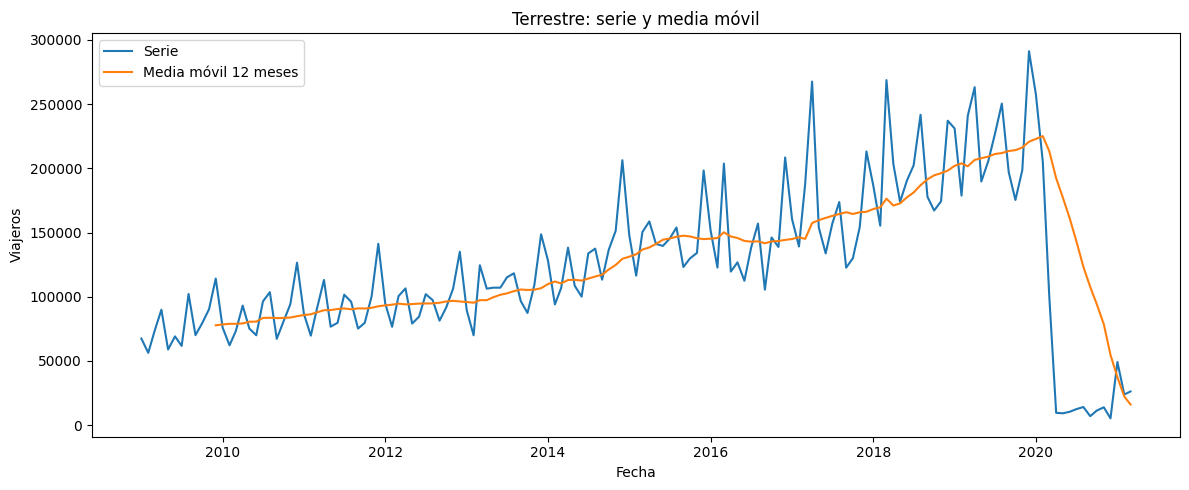

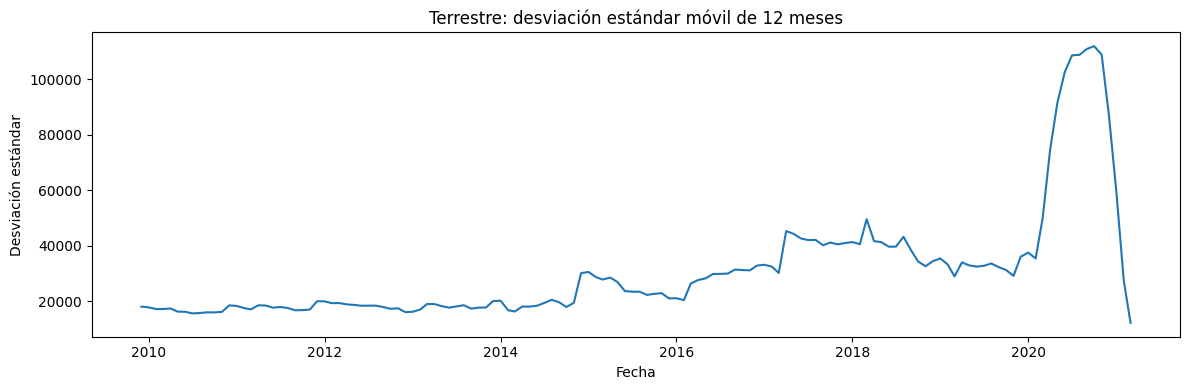

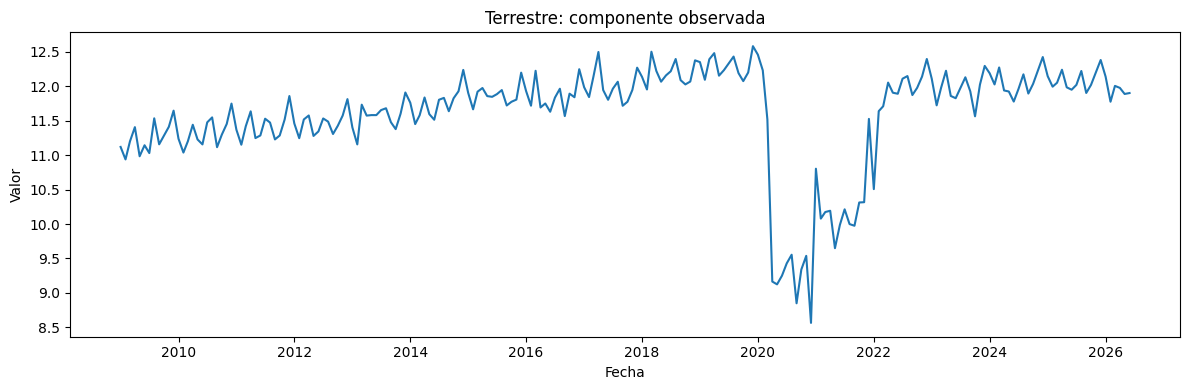

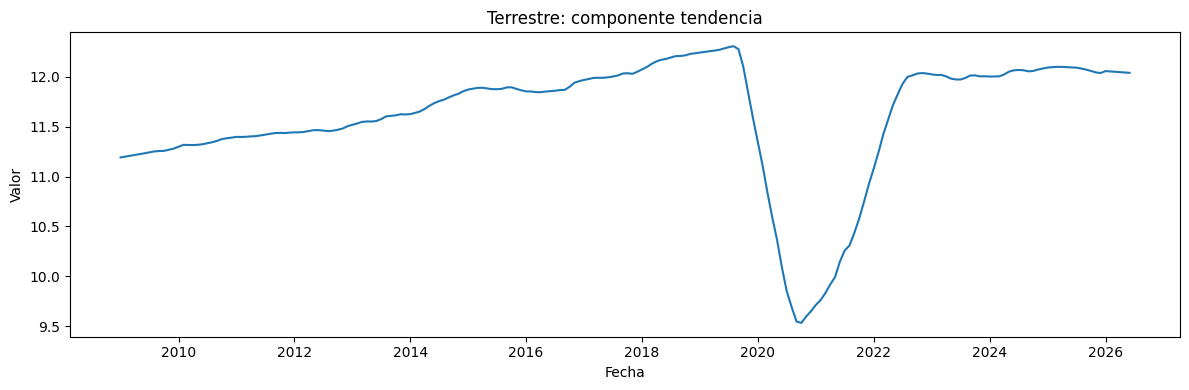

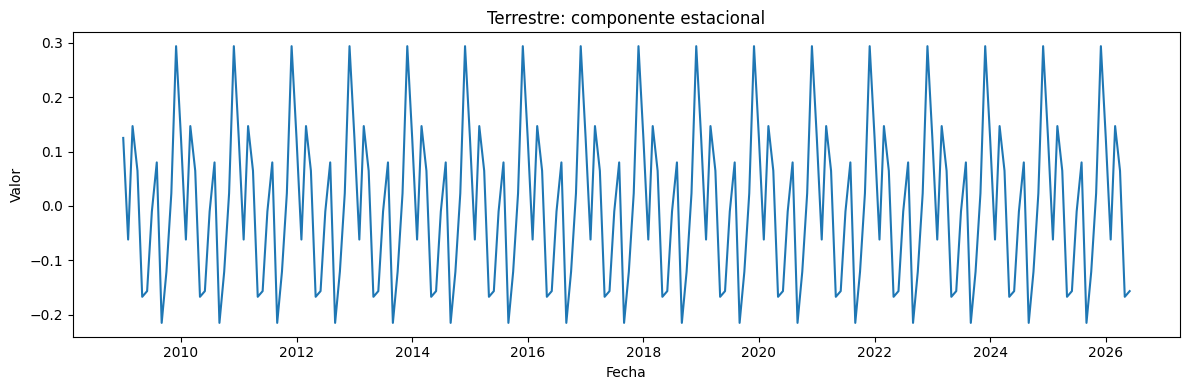

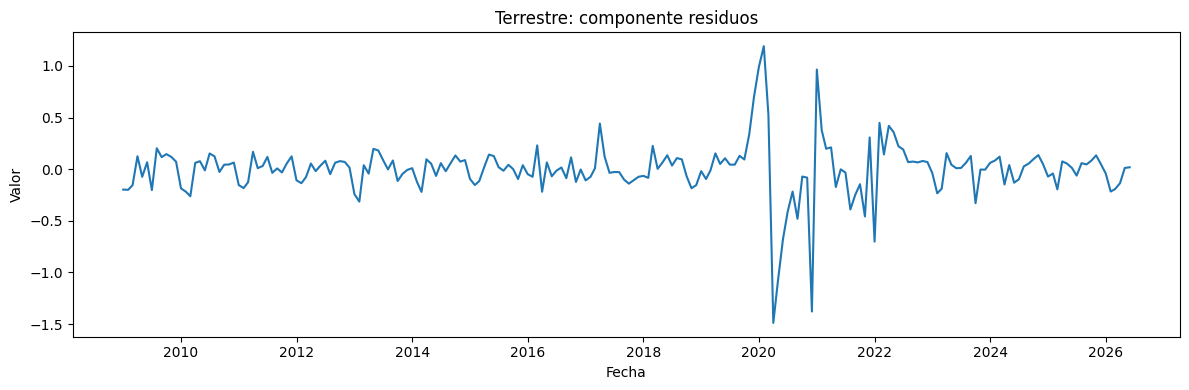

Prueba de Dickey-Fuller aumentada:


,Transformación,Estadístico ADF,p-value,Lags usados,Observaciones,Conclusión 5%
0,Serie original,-2.117165,0.237669,13,133,No estacionaria en media
1,log(1 + x),-2.022893,0.276626,13,133,No estacionaria en media
2,Primera diferencia de log(1 + x),-3.123419,0.024868,11,134,Estacionaria en media
3,Primera diferencia + diferencia estacional 12,-5.488908,0.000002,11,122,Estacionaria en media


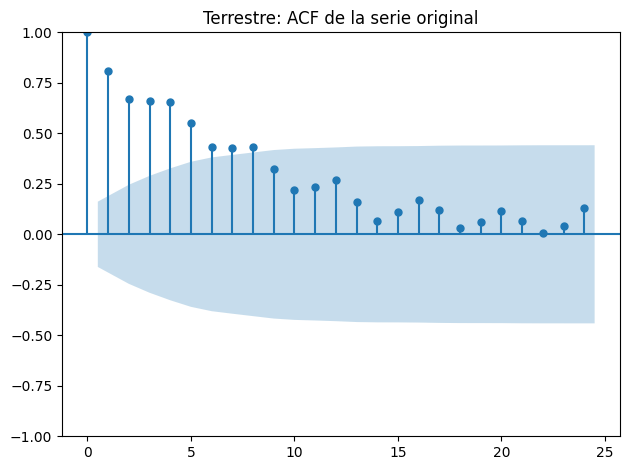

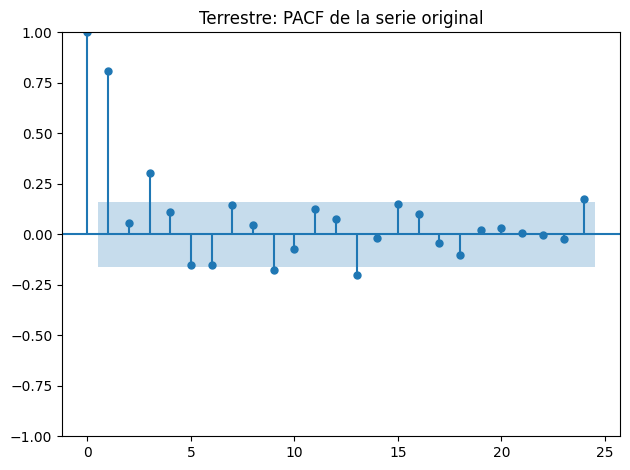

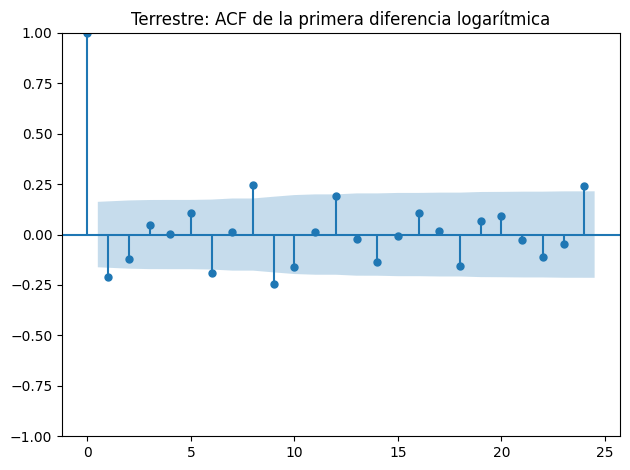

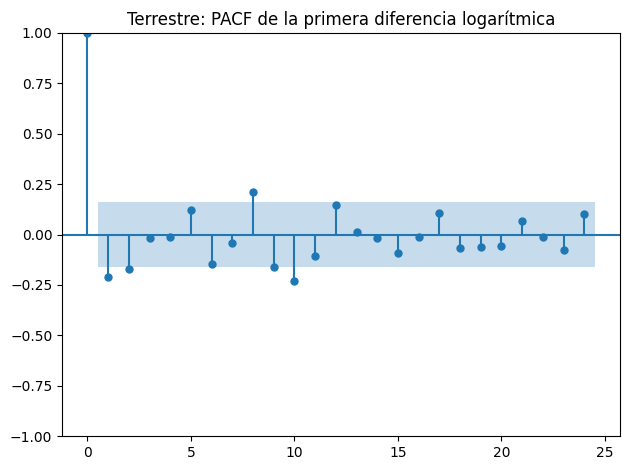

Serie,Aérea,Terrestre
Inicio,2009-01,2009-01
Fin,2026-06,2026-06
Frecuencia,Mensual (12/año),Mensual (12/año)
Observaciones,210,210
Media,90568.659779,131391.682537
Desviación estándar,27855.303128,60815.994809
Coeficiente de variación,0.30756,0.46286
Mínimo,489.0,5240.0
Fecha mínimo,2020-04,2020-12
Máximo,158463.0,291272.0705


Archivos generados:
- C:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\lab1\diagnostico_series.csv
- C:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\lab1\figures\01_boxplot_viajero.png
- C:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\lab1\figures\02_total_mensual.png
- C:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\lab1\figures\03_total_anual.png
- C:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\lab1\figures\04_top_paises.png
- C:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\lab1\figures\05_top_regiones.png
- C:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\lab1\figures\06_vias_ingreso.png
- C:

In [8]:
resumen_aerea, adf_aerea = analizar_serie(
    "Aérea",
    series_vias["Aérea"],
    fecha_fin_train,
)

resumen_terrestre, adf_terrestre = analizar_serie(
    "Terrestre",
    series_vias["Terrestre"],
    fecha_fin_train,
)

diagnostico_series = pd.DataFrame(
    [resumen_aerea, resumen_terrestre]
).set_index("Serie")
display(diagnostico_series.T)

diagnostico_series.to_csv(
    OUTPUT_DIR / "diagnostico_series.csv",
    encoding="utf-8-sig",
)

print("Archivos generados:")
for archivo in sorted(OUTPUT_DIR.rglob("*")):
    if archivo.is_file():
        print("-", archivo)